<a href="https://colab.research.google.com/github/rajkgoel/AW-Internet-Sales1/blob/master/ViT_%26_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ViT & CLIP
Learning path
-
Vision Transformer (ViT)
 - Why CNNs were traditionally used for images
 - How an image becomes a sequence of tokens
 - Patch embeddings
 - Positional embeddings
 - Self-attention on image patches
 - [CLS] token and image representation
 - ViT architecture

CLIP
 - Why CLIP needs both an image encoder and a text encoder
 - Image and text embeddings
 - Contrastive learning
 - How image ↔ text matching works
 - Zero-shot classification
 - How CLIP differs from a normal ViT

Connect the concepts
 - CNN vs ViT
 - ViT vs CLIP
 - CLIP vs traditional image classification
 - Where these models fit into modern multimodal AI

Imagine we have this image:

🐱 A cat sitting on a chair

A CNN naturally looks at the image through local filters. But a Transformer expects something different: a sequence of tokens.

So here's the key question:

*How could we convert a 2D image into a sequence of tokens that a Transformer can process?*


Why Vision Transformer (ViT)?
-

  A normal Transformer works with a sequence of tokens:

“The cat is sleeping” → [The] [cat] [is] [sleeping]

But an image is a 2D grid of pixels, not a sequence.

So ViT's main idea is surprisingly simple:

Convert an image into a sequence of small image patches, then process those patches like tokens.

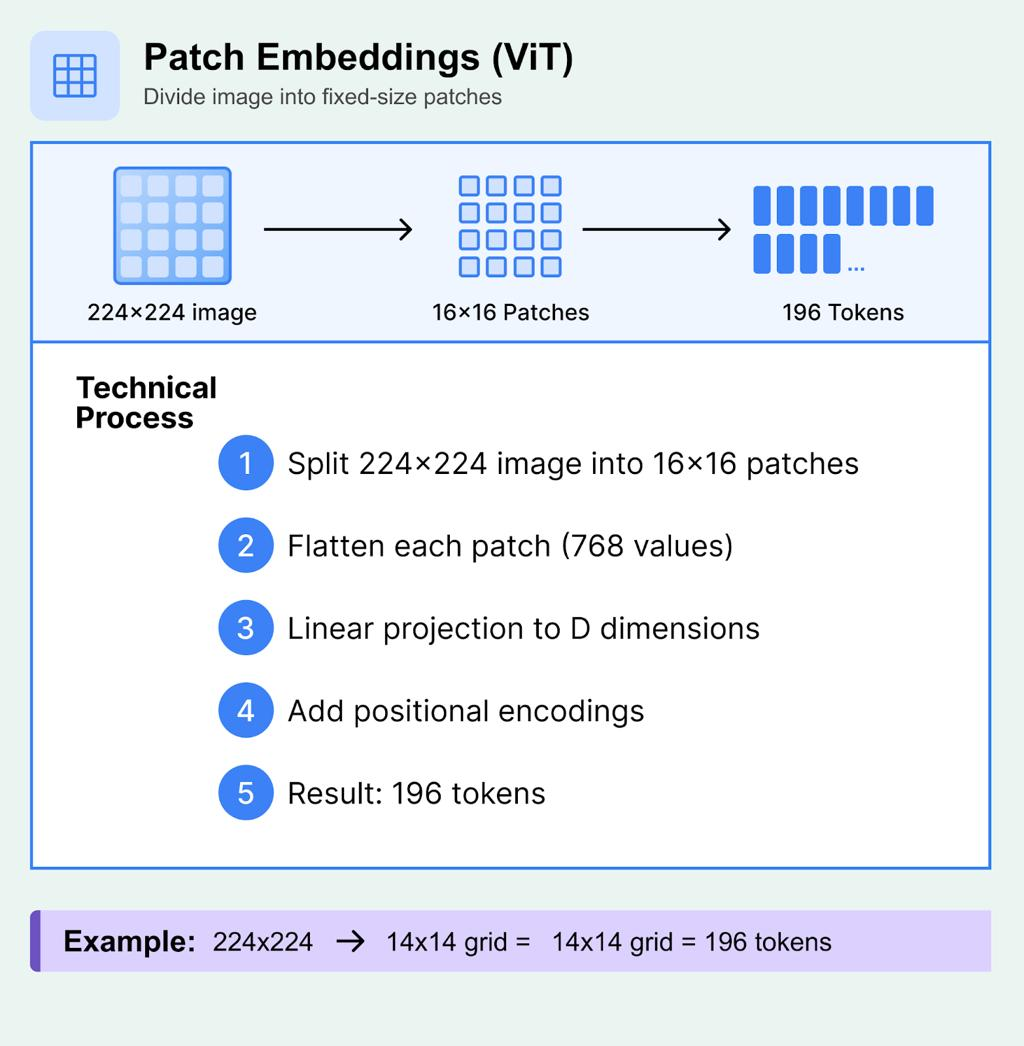

Image → Patches
-
Suppose we have a 224 × 224 RGB image.

ViT might divide it into patches of 16 × 16 pixels.

Number of patches:

> 224/16 ×  224/16 = 14×14 = 196

So instead of treating the image as 50,176 pixels, we now have:

196 image patches

Each patch becomes analogous to a token in NLP.

**NLP**

"The cat is sleeping"
       ↓
   4 tokens

**ViT**

> 224 × 224 image

>      ↓

> 16 × 16 patches

>       ↓

> 196 patches/tokens

Patch → Embedding
-
A patch is initially just pixel values.

For RGB:

16×16×3=768

So each patch can be flattened into a vector of 768 numbers.

ViT then applies a learned linear projection to convert that vector into an embedding.

For example:
```
Patch 1 → [0.21, -0.45, 0.73, ...]
Patch 2 → [0.12,  0.82, 0.11, ...]
...
Patch 196 → [...]
```
Now we have something very similar to word embeddings.

Positional Embedding
-

Consider:

Patch A Patch B
Patch C Patch D

Without positional information, the Transformer might know that A, B, C and D exist, but not inherently know their locations.

So ViT adds positional embeddings:

> Patch embedding + Position embedding

>         ↓

>    Transformer

Thus the model knows:

"This patch came from the top-left."

"This patch came from the bottom-right."

Self-Attention
-
Now the really interesting part.

The 196 patch embeddings are passed through the Transformer.

Self-attention allows one patch to interact with all other patches.

For example, suppose:

🐱

is spread across several patches.

A patch containing the cat's ear can attend to patches containing:

 - the cat's face
 - the cat's body
 - the chair
 - the background

So the Transformer can learn relationships between distant parts of the image.

This is one major difference from traditional CNN processing.

[CLS] Token
-
ViT also introduces a special classification token, similar to BERT.

Conceptually:

[CLS] Patch1 Patch2 Patch3 ... Patch196

After passing through the Transformer, the [CLS] representation is used as the overall representation of the image.

For example:

```
Image
 ↓
Patches
 ↓
Patch embeddings
 ↓
+ positional embeddings
 ↓
Transformer
 ↓
[CLS] representation
 ↓
Classification head
 ↓
"CAT"
```

The complete ViT pipeline
-
Keep this mental picture:
```
              IMAGE
                ↓
        Divide into patches
                ↓
       Patch 1 ... Patch 196
                ↓
         Patch embeddings
                ↓
      + positional embeddings
                ↓
          Transformer
       ┌─────────────────┐
       │ Self-Attention   │
       │ Feed Forward     │
       │ Self-Attention   │
       │ Feed Forward     │
       │       ...        │
       └─────────────────┘
                ↓
           [CLS] vector
                ↓
        Classification head
                ↓
             CAT
```

The key analogy

| NLP Transformer        | Vision Transformer           |
| ---------------------- | ---------------------------- |
| Word/token             | Image patch                  |
| Word embedding         | Patch embedding              |
| Positional encoding    | Positional embedding         |
| Sentence               | Image                        |
| `[CLS]` representation | `[CLS]` image representation |
| Transformer            | Transformer                  |

The revolutionary idea of ViT is essentially:

Treat image patches like words and use a Transformer to understand their relationships.

#CLIP - Contrastive Language Image Pretraining

CLIP takes this idea one step further.

Instead of only asking:

"What class is this image?"

CLIP learns a relationship between images and text.

It has two encoders:

```
             IMAGE
               ↓
         Image Encoder
               ↓
         Image Embedding
               ↘
                 Similarity
               ↗
          Text Embedding
               ↑
          Text Encoder
               ↑
        "A photo of a cat"
```

The image encoder can be a ViT.

The text encoder is a Transformer-based text model.

During training, CLIP receives matching image-text pairs:

> Image: 🐱
>
> Text: "A cat sitting on a chair"

and learns to make their embeddings close together.

For unrelated pairs:

>Image: 🐱
>
>Text: "A red sports car"

it learns to make their embeddings farther apart.

This is called contrastive learning.

Why CLIP is powerful
-

Once image and text live in the same embedding space, you can do zero-shot classification.

Suppose you have an image and these candidate texts:
```
"A dog"
"A cat"
"A horse"
```
CLIP calculates:
```
Image ↔ "A dog"    → similarity 0.31
Image ↔ "A cat"    → similarity 0.89
Image ↔ "A horse"  → similarity 0.22
```
The highest similarity is:

A cat

No dedicated "cat classifier" necessarily needs to be trained for that specific classification task.

One-line distinction to remember
-
**ViT:**

> 🖼️ Image → Transformer → image representation

**CLIP:**

> 🖼️ Image → image embedding
> 📝 Text → text embedding
> → compare them in the same embedding space

And this connects directly to what you've already learned about embeddings and vector similarity: CLIP essentially uses that same idea to connect vision and language.

# ViT Example

In [1]:
!pip install -q transformers torch torchvision pillow

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

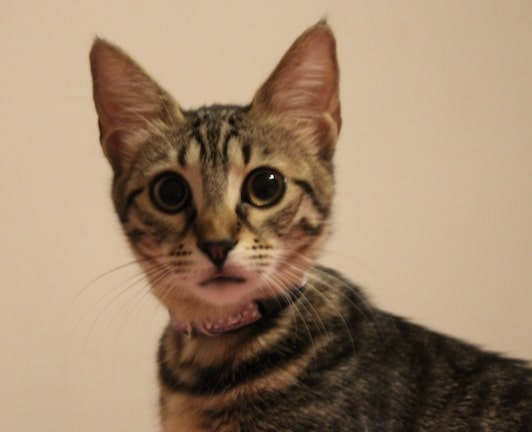

In [2]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

# Load pretrained ViT
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224"
)

# Download an example image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/cat.jpg"

image = Image.open(requests.get(url, stream=True).raw)

image

In [3]:
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)

predicted_class = outputs.logits.argmax(-1).item()

print(model.config.id2label[predicted_class])

tabby, tabby cat


```
Image
  ↓
224 × 224
  ↓
16 × 16 patches
  ↓
196 patches
  ↓
Patch embeddings
  ↓
Positional embeddings
  ↓
Transformer
  ↓
Classification
```

# CLIP Example

In [4]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

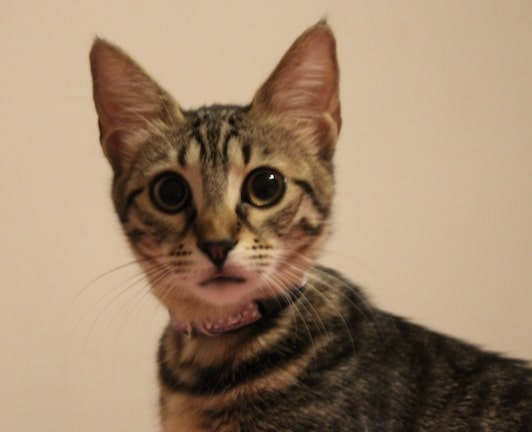

In [5]:
# Load an image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/cat.jpg"

image = Image.open(requests.get(url, stream=True).raw)
image

In [6]:
texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a bird"
]

# Process both image and text
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)

probs = outputs.logits_per_image.softmax(dim=1)

for text, probability in zip(texts, probs[0]):
    print(f"{text}: {probability.item():.3f}")

a photo of a cat: 0.995
a photo of a dog: 0.004
a photo of a car: 0.000
a photo of a bird: 0.001
